In [ ]:
!git clone https://github.com/NhatHienUIT/MangoLeaf.git /content/MangoLeaf

Cloning into '/content/MangoLeaf'...
remote: Enumerating objects: 2547, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 2547 (delta 9), reused 0 (delta 0), pack-reused 2508 (from 1)
Receiving objects: 100% (2547/2547), 67.77 MiB | 14.83 MiB/s, done.
Resolving deltas: 100% (183/183), done.
Updating files: 100% (2513/2513), done.


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
import joblib
from google.colab.patches import cv2_imshow
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import roc_curve, auc
from google.colab.patches import cv2_imshow
from joblib import Parallel, delayed


#Thực nghiệm

In [ ]:
input_dir = "/content/MangoLeaf/evaluation"
categories = ['Khỏe mạnh','Bị sâu bệnh']

data = []
labels = []
datas = []
labelss = []
for idx,category in enumerate(categories):
  print(f"Loading image from category: {category}")
  if category != 'Khỏe mạnh' :
    idx = 1
  class_dir = os.path.join(input_dir,category)
  for img_name in os.listdir(class_dir) :
    img_dir = os.path.join(class_dir,img_name)
    img = cv2.imread(img_dir)
    datas.append(img)
    labelss.append(idx)
    img = cv2.resize(img,(64,64))
    data.append(img)
    labels.append(idx)
data = np.asarray(data)
labels = np.asarray(labels)

Loading image from category: Khỏe mạnh
Loading image from category: Bị sâu bệnh


In [ ]:
def feature_histogram(img) :
  hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
  hist = hist/hist.max()
  return hist.flatten()

In [ ]:
def plot_classification_results(data_test, y_test, y_pred, images=None):
    correct_indices = np.where(y_pred == y_test)[0]
    incorrect_indices = np.where(y_pred != y_test)[0]

    display_images(data_test, y_test, y_pred,correct_indices, "Ảnh phân loại đúng", 4)
    display_images(data_test, y_test, y_pred,incorrect_indices, "Ảnh phân loại sai", 2)


In [ ]:
def display_images(data_test,y_test, y_pred, indices, title, n):
    if len(indices) < n:
        n = len(indices)
    plt.figure(figsize=(25, 5))
    true_vals = []
    pred = []
    for idx, i in enumerate(y_test):
        if i == 1:
          true_vals.append("Bị sâu bệnh")
        else:
          true_vals.append("Khỏe mạnh")
    for idx, i in enumerate(y_pred):
        if i == 1:
          pred.append("Bị sâu bệnh")
        else:
          pred.append("Khỏe mạnh")
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        plt.imshow(data_test[idx])
        plt.title(f"Phân loại: {pred[idx]}\nLớp thực: {true_vals[idx]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


In [ ]:
X_eval = [feature_histogram(i) for i in data]
X_eval = np.asarray(X_eval)


In [ ]:
def plot_classification_evaluation(data_test, y_test, y_pred, images=None):
    correct_indices = np.where(y_pred == y_test)[0]
    incorrect_indices = np.where(y_pred != y_test)[0]

    display_images(data_test, y_test, y_pred,correct_indices, "Ảnh phân loại đúng", 8)
    display_images(data_test, y_test, y_pred,incorrect_indices, "Ảnh phân loại sai", 8)

Test Accuracy Score: 1.0
F1 Score (weighted): 1.0
Confusion Matrix:
 [[5 0]
 [0 4]]


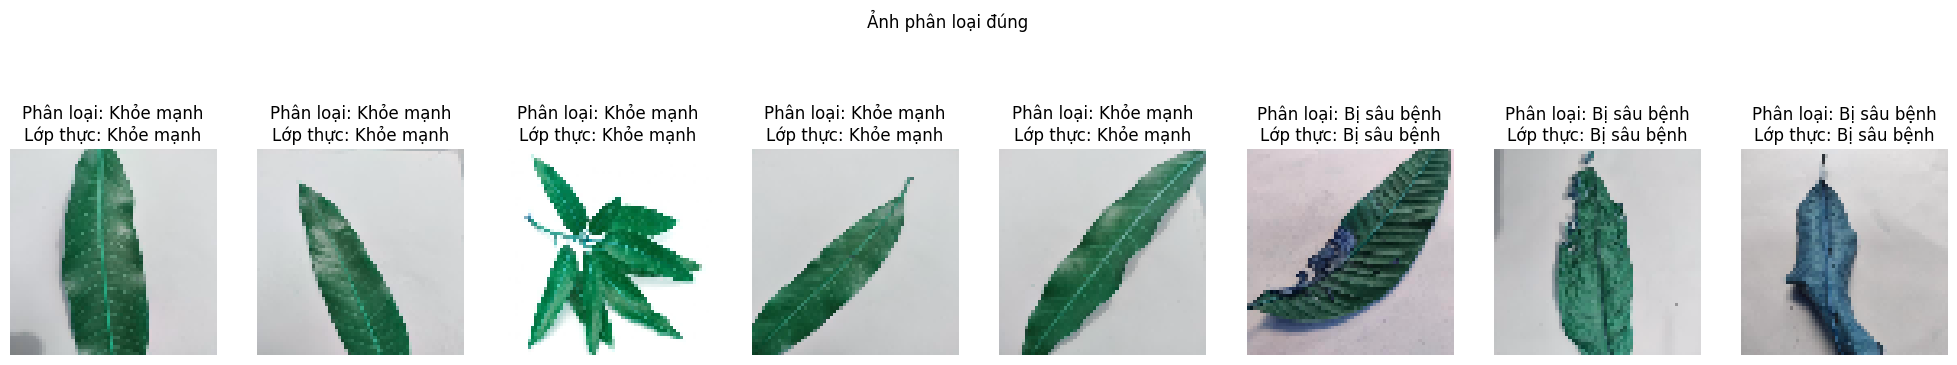

<Figure size 2500x500 with 0 Axes>

In [ ]:
his_svc = joblib.load('MangoLeaf/his_svc.pkl')
y_eval = his_svc.predict(X_eval)
print("Test Accuracy Score:", accuracy_score(y_eval, labels))
print("F1 Score (weighted):", f1_score(y_eval, labels, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_eval, labels))
plot_classification_evaluation(data, y_eval, labels)